In [8]:
!git clone -b imasha https://github.com/nadroj0-0/Applied-Deep-Learning-COMP019-GROUP.git
%cd Applied-Deep-Learning-COMP019-GROUP
import sys
from utils.data import load_batches
import pandas as pd
import numpy as np
import lightgbm as lgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from google.colab import drive
import gc
drive.mount('/content/drive')

Cloning into 'Applied-Deep-Learning-COMP019-GROUP'...
remote: Enumerating objects: 317, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 317 (delta 27), reused 47 (delta 14), pack-reused 239 (from 1)
Receiving objects: 100% (317/317), 458.20 MiB | 27.47 MiB/s, done.
Resolving deltas: 100% (107/107), done.
Updating files: 100% (75/75), done.
/content/Applied-Deep-Learning-COMP019-GROUP/Applied-Deep-Learning-COMP019-GROUP
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# This code creates a LightGBM and Neural Network hybrid model. A NN is used to learn patterns such as item demand and seasonality etc, -> the item embeddings. The embeddings are then fed back into the dataset in batches to handle memory constraints. Then the learned embeddings are fed into the LightGBM, and is trained on these batches using quantile loss. Three LightGBM models are trained, one that predicts the mean, one that predicts the 25th quantile and one for the 75th quantile. The main prediction is the mean model, with the predictions of the 25th and 75th quantiles acting like prediction intervals.

Using Luke's code to download the datasets

In [9]:
def download_m5_data():
    print("Downloading M5 dataset...")

    sales = pd.read_csv(
        "https://huggingface.co/datasets/kashif/M5/resolve/main/sales_train_evaluation.csv"
    )

    calendar = pd.read_csv(
        "https://huggingface.co/datasets/kashif/M5/resolve/main/calendar.csv"
    )

    prices = pd.read_csv(
        "https://huggingface.co/datasets/kashif/M5/resolve/main/sell_prices.csv"
    )

    return sales, calendar, prices


sales, calendar, prices = download_m5_data()
# filter to only CA_3 store
sales = sales[sales["store_id"] == "CA_3"].copy()
prices = prices[prices["store_id"] == "CA_3"].copy()

print("Filtered sales shape:", sales.shape)
print("Filtered prices shape:", prices.shape)


Filtered sales shape: (3049, 1947)
Filtered prices shape: (693990, 4)


Using Sherwin's code to build a subset of features that the feature importance tests said were useful

In [10]:
import numpy as np
import pandas as pd


def create_calendar_features(calendar):
    calendar = calendar.copy()
    calendar["date"] = pd.to_datetime(calendar["date"])
    calendar["d_num"] = calendar["d"].str[2:].astype(int)

    calendar["week_of_year"] = calendar["date"].dt.isocalendar().week.astype(int)
    calendar["quarter"] = calendar["date"].dt.quarter
    calendar["day_of_month"] = calendar["date"].dt.day
    calendar["day_of_year"] = calendar["date"].dt.dayofyear

    calendar["is_weekend"] = calendar["weekday"].isin(["Saturday", "Sunday"]).astype(int)
    calendar["is_event_day"] = (
        (calendar["event_name_1"].notna()) |
        (calendar["event_name_2"].notna())
    ).astype(int)

    calendar["wday_sin"] = np.sin(2 * np.pi * calendar["wday"] / 7)
    calendar["wday_cos"] = np.cos(2 * np.pi * calendar["wday"] / 7)

    return calendar


def create_price_features(prices):
    prices = prices.sort_values(["store_id", "item_id", "wm_yr_wk"])
    grp = prices.groupby(["store_id", "item_id"])

    prices["price_lag_1w"] = grp["sell_price"].shift(1)
    prices["price_change_1w"] = prices["sell_price"] - prices["price_lag_1w"]
    prices["price_pct_change_1w"] = prices["sell_price"] / prices["price_lag_1w"] - 1

    for w in [4, 13, 52]:
        prices[f"price_roll_mean_{w}w"] = grp["sell_price"].transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).mean()
        )
        prices[f"price_rel_{w}w"] = prices["sell_price"] / prices[f"price_roll_mean_{w}w"]

    prices["price_rel_dept_store"] = prices["sell_price"] / prices.groupby(
        ["dept_id", "store_id", "wm_yr_wk"]
    )["sell_price"].transform("mean")

    prices["price_rank_dept_store"] = prices.groupby(
        ["dept_id", "store_id", "wm_yr_wk"]
    )["sell_price"].rank(pct=True)

    prices["price_change_flag_1w"] = (prices["price_change_1w"] != 0).astype(int)

    return prices


def create_sales_features(df):
    df = df.sort_values(["id", "d_num"])
    grp = df.groupby("id")["sales"]

    for lag in [1, 7, 14, 28, 56]:
        df[f"sales_lag_{lag}"] = grp.shift(lag)

    for w in [7, 28, 56]:
        df[f"sales_roll_mean_{w}"] = grp.transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).mean()
        )

    df["sales_roll_std_28"] = grp.transform(
        lambda x: x.shift(1).rolling(28).std()
    )

    df["sales_roll_nonzero_rate_28"] = (
        (df["sales"] > 0)
        .groupby(df["id"])
        .transform(lambda x: x.shift(1).rolling(28).mean())
    )

    df["sale_occurrence"] = (df["sales"] > 0).astype(int)

    return df


def create_hierarchy_features(df, group_cols, prefix):
    agg = df.groupby(group_cols + ["d"])["sales"].sum().reset_index()

    grp = agg.groupby(group_cols)["sales"]

    agg[f"{prefix}_sales_lag_7"] = grp.shift(7)
    agg[f"{prefix}_sales_lag_28"] = grp.shift(28)

    agg[f"{prefix}_sales_roll_mean_7"] = grp.transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
    agg[f"{prefix}_sales_roll_mean_28"] = grp.transform(
        lambda x: x.shift(1).rolling(28).mean()
    )

    return agg


def build_features(sales, calendar, prices):

    day_cols = [c for c in sales.columns if c.startswith("d_")]

    df = sales.melt(
        id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
        value_vars=day_cols,
        var_name="d",
        value_name="sales"
    )

    df["d_num"] = df["d"].str[2:].astype(int)

    calendar = create_calendar_features(calendar)
    df = df.merge(calendar, on=["d", "d_num"], how="left")

    prices = create_price_features(prices)

    df = df.merge(
        prices.drop(columns=["dept_id", "cat_id"]),
        on=["store_id", "item_id", "wm_yr_wk"],
        how="left"
    )


    df = create_sales_features(df)

    dept_store = create_hierarchy_features(df, ["dept_id", "store_id"], "dept_store")

    df = df.merge(
        dept_store[
            [
                "dept_id", "store_id", "d",
                "dept_store_sales_lag_7",
                "dept_store_sales_lag_28",
                "dept_store_sales_roll_mean_7",
                "dept_store_sales_roll_mean_28"
            ]
        ],
        on=["dept_id", "store_id", "d"],
        how="left"
    )

    return df

# Start the preprocessing

In [11]:
# keeping only the first 150 days
day_cols = [c for c in sales.columns if c.startswith("d_")]
sales_small = sales[["id","item_id","dept_id","cat_id","store_id","state_id"] + day_cols[:300]]

# turn this data into strings
sales["item_id"] = sales["item_id"].astype(str)
prices["item_id"] = prices["item_id"].astype(str)

# get the metadata and get rid of any duplicates
item_meta = sales[["item_id", "dept_id", "cat_id"]].drop_duplicates()

# the prices dataset also has these columns, drop them so there are no clashes
prices = prices.drop(columns=["dept_id", "cat_id"], errors="ignore")

# merge the datasets
prices = prices.merge(item_meta, on="item_id", how="left")

print("Prices columns after merge:", prices.columns)

# build all the datasets into one large dataset
df = build_features(sales_small, calendar, prices)

print("Final dataset shape:", df.shape)
df.head()

Prices columns after merge: Index(['store_id', 'item_id', 'wm_yr_wk', 'sell_price', 'dept_id', 'cat_id'], dtype='object')
Final dataset shape: (914700, 58)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,d_num,date,...,sales_roll_mean_7,sales_roll_mean_28,sales_roll_mean_56,sales_roll_std_28,sales_roll_nonzero_rate_28,sale_occurrence,dept_store_sales_lag_7,dept_store_sales_lag_28,dept_store_sales_roll_mean_7,dept_store_sales_roll_mean_28
0,FOODS_1_001_CA_3_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,d_1,1,1,2011-01-29,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
1,FOODS_1_001_CA_3_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,d_2,2,2,2011-01-30,...,1.000000,1.000000,1.000000,NaN,NaN,1,248.0,224.0,244.000000,252.250000
2,FOODS_1_001_CA_3_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,d_3,1,3,2011-01-31,...,1.500000,1.500000,1.500000,NaN,NaN,1,204.0,385.0,279.285714,303.071429
3,FOODS_1_001_CA_3_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,d_4,1,4,2011-02-01,...,1.333333,1.333333,1.333333,NaN,NaN,1,264.0,244.0,286.571429,289.785714
4,FOODS_1_001_CA_3_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,d_5,1,5,2011-02-02,...,1.250000,1.250000,1.250000,NaN,NaN,1,332.0,378.0,266.714286,273.857143


In [12]:
# time series need to be ordered
df = df.sort_values(["id","d_num"])
# just rename to be time index feature
df["time_index"] = df["d_num"]
# encode categorical IDs
df["item_id"] = df["item_id"].astype("category").cat.codes.astype(np.int64)
# drop store id column
df = df.drop(columns=["store_id"])
# find the very last 28 days in the dataset
# earlier days are for training
#last 28 days are for validation
cutoff = df["d_num"].max() - 28
# split into training and validation
train = df[df["d_num"] <= cutoff].copy()
valid = df[df["d_num"] > cutoff].copy()
# target should not be in the training set, things like id and day also do not count
X_train = train.drop(columns=["sales","id","d"]).copy()
y_train = train["sales"]
# repeat for validation set
X_valid = valid.drop(columns=["sales","id","d"]).copy()
y_valid = valid["sales"]

print("df shape:", df.shape)
print("train shape:", train.shape)
print("valid shape:", valid.shape)
print("min d:", df["d_num"].min(), "max d:", df["d_num"].max())

df shape: (914700, 58)
train shape: (829328, 58)
valid shape: (85372, 58)
min d: 1 max d: 300


In [13]:
# drop raw date as its very large
X_train = X_train.drop(columns=["date"])
X_valid = X_valid.drop(columns=["date"])

# encode the object columns into integer variables
for col in X_train.columns:
    if X_train[col].dtype == "object":
        X_train[col] = X_train[col].astype("category").cat.codes
        X_valid[col] = X_valid[col].astype("category").cat.codes

# replace invalid values with 0
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan).fillna(0)

# convert to float 32 to reduce memory
X_train = X_train.astype(np.float32)
X_valid = X_valid.astype(np.float32)

# SAMPLING
# use only 20% of the training data as the dataset is huge
train_sample = train.sample(frac=0.2, random_state=42)

X_train_sample = train_sample.drop(columns=["sales","id","d"])

# drop the date as it uses up too much memory
X_train_sample = X_train_sample.drop(columns=["date"])
# define target
y_train_sample = train_sample["sales"]

# encode object columns
for col in X_train_sample.columns:
    if X_train_sample[col].dtype == "object":
        X_train_sample[col] = X_train_sample[col].astype("category").cat.codes

# replace invalid data with 0s
X_train_sample = X_train_sample.replace([np.inf, -np.inf], np.nan).fillna(0)

# to save memory use float32
X_train_sample = X_train_sample.astype(np.float32)
# standardise all the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_sample.drop(columns=["item_id"])
)

# free memory
del X_train
del X_valid

# create the tensors for the NN
X_train_num = torch.tensor(X_train_scaled, dtype=torch.float32)

item_ids_train = torch.tensor(train_sample["item_id"].values, dtype=torch.long)

y_train_tensor = torch.tensor(y_train_sample.values, dtype=torch.float32).view(-1,1)

In [14]:
import torch
import torch.nn as nn

class HybridNN(nn.Module):
    def __init__(self, n_items, input_dim):
        super().__init__()
        # map each item ID into a 16 dimentional vector
        self.item_emb = nn.Embedding(n_items, 16)

        self.fc = nn.Sequential(
            nn.Linear(input_dim + 16, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.head = nn.Linear(64, 1)

    def forward(self, x_num, item_id):
        item_vec = self.item_emb(item_id)

        x = torch.cat([x_num, item_vec], dim=1)

        hidden = self.fc(x)
        pred = self.head(hidden)

        return pred, hidden

In [16]:
# create the model
model_nn = HybridNN(
    n_items=train_sample["item_id"].nunique(),
    input_dim=X_train_num.shape[1]
)

optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.0005)
loss_fn = nn.MSELoss()

# train the model on the sampled data
for epoch in range(100):
    optimizer.zero_grad()

    preds, _ = model_nn(X_train_num, item_ids_train)

    loss = loss_fn(preds, y_train_tensor)
    # make sure loss is not NaN
    if torch.isnan(loss):
        print("NaN loss detected — stopping")
        break

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}: {loss.item():.4f}")

Epoch 0: 30.5893
Epoch 5: 29.7323
Epoch 10: 28.8060
Epoch 15: 27.7188
Epoch 20: 26.3924
Epoch 25: 24.7894
Epoch 30: 22.8951
Epoch 35: 20.7259
Epoch 40: 18.3607
Epoch 45: 15.9516
Epoch 50: 13.7156
Epoch 55: 11.8524
Epoch 60: 10.4821
Epoch 65: 9.5798
Epoch 70: 9.0399
Epoch 75: 8.7225
Epoch 80: 8.5127
Epoch 85: 8.3357
Epoch 90: 8.1702
Epoch 95: 8.0217


In [17]:
def add_nn_embeddings_stream(df_part, model_nn, scaler, prefix, batch_size=50_000):
    # use GPU if available, otherwise CPU
    # just fastens the process and puts less pressure on CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_nn.to(device)
    # Store the file paths of saved batches
    output_files = []
    # loop over each batch
    for start in range(0, len(df_part), batch_size):
        end = start + batch_size
        # extrat the batch
        batch = df_part.iloc[start:end].copy()
        # prepare the features
        X = batch.drop(columns=["sales","id","d","date"])
        # encode the categorical features
        for col in X.columns:
            if X[col].dtype == "object":
                X[col] = X[col].astype("category").cat.codes
        # handle any missing values
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32)
        # scale the data, but do not scale item_id
        X_scaled = scaler.transform(
            X.drop(columns=["item_id"])
        )

        # convert to tensors
        X_num = torch.tensor(X_scaled, dtype=torch.float32).to(device)
        item_ids = torch.tensor(batch["item_id"].values, dtype=torch.long).to(device)
        # pass through NN
        with torch.no_grad():
            _, latent = model_nn(X_num, item_ids)
        # convert results back to NumPy
        latent = latent.cpu().numpy()

        # add the learned features from the NN back into the dataset
        for i in range(latent.shape[1]):
            batch[f"nn_feat_{i}"] = latent[:, i]

        # Save each batch to the google drive disk
        file_name = f"/content/drive/MyDrive/m5_pipeline_batches/{prefix}_batch_{start}.pkl"
        batch.to_pickle(file_name)
        # store its file path
        output_files.append(file_name)

        # Delete any memory we dont need to free up space
        del batch, X, X_scaled, X_num, item_ids, latent
        gc.collect()

        print(f"Saved {file_name}")

    return output_files

train_files = add_nn_embeddings_stream(train, model_nn, scaler, prefix="train")
valid_files = add_nn_embeddings_stream(valid, model_nn, scaler, prefix="valid")

Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_0.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_50000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_100000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_150000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_200000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_250000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_300000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_350000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_400000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_450000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_500000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_550000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_600000.pkl
Saved /content/drive/MyDrive/m5_pipeline_batches/train_batch_650000.pk

In [18]:
import lightgbm as lgb
import pandas as pd
import numpy as np

def prepare_lgb(df):
    df = df.copy()
    # drop the date
    if "date" in df.columns:
        df = df.drop(columns=["date"])
    # encode categorical data
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype("category").cat.codes
    # handle incorrect or NaN values
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

    return df

In [19]:
# load the first batch and prepare the data for the light GBM
first_batch = pd.read_pickle(train_files[0])
first_batch = prepare_lgb(first_batch)
# drop unwanted features and set target feature
X = first_batch.drop(columns=["sales","id","d"])
y = first_batch["sales"]
# create all three models
lgb_mean = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=128
)

lgb_25 = lgb.LGBMRegressor(
    objective="quantile",
    alpha=0.25,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=128
)

lgb_75 = lgb.LGBMRegressor(
    objective="quantile",
    alpha=0.75,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=128
)


In [20]:
def train_model(model):

    first_batch = pd.read_pickle(train_files[0])
    first_batch = prepare_lgb(first_batch)

    X = first_batch.drop(columns=["sales","id","d"])
    y = first_batch["sales"]

    model.fit(X, y)

    for file in train_files[1:]:
        print("Training on:", file)

        batch = pd.read_pickle(file)
        batch = prepare_lgb(batch)

        X_batch = batch.drop(columns=["sales","id","d"])
        y_batch = batch["sales"]

        model.fit(X_batch, y_batch, init_model=model)

        del batch

    return model


lgb_mean = train_model(lgb_mean)
lgb_25   = train_model(lgb_25)
lgb_75   = train_model(lgb_75)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032060 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20785
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 113
[LightGBM] [Info] Start training from score 1.185780
Training on: /content/drive/MyDrive/m5_pipeline_batches/train_batch_50000.pkl
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048887 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21267
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 114
Training on: /content/drive/MyDrive/m5_pipeline_batches/train_batch_100000.pkl
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testin

In [22]:
import os
import torch
import joblib
import shutil

BASE_PATH = "/content/drive/MyDrive/m5_pipeline/"
BATCH_PATH = "/content/drive/MyDrive/m5_pipeline_batches/"

os.makedirs(BASE_PATH, exist_ok=True)
os.makedirs(BATCH_PATH, exist_ok=True)

print("Saving to:", BASE_PATH)

# mean model
lgb_mean.booster_.save_model(BASE_PATH + "lgb_mean.txt")
print("Saved lgb_mean")

# 25th percentile
try:
    lgb_25.booster_.save_model(BASE_PATH + "lgb_25.txt")
    print("Saved lgb_25")
except:
    print("lgb_25 not found")

# 75th percentile
try:
    lgb_75.booster_.save_model(BASE_PATH + "lgb_75.txt")
    print("Saved lgb_75")
except:
    print("lgb_75 not found")

torch.save(model_nn.state_dict(), BASE_PATH + "nn_model.pth")
print("Saved NN model")

joblib.dump(scaler, BASE_PATH + "scaler.pkl")
print("Saved scaler")

try:
    train.to_pickle(BASE_PATH + "train_final.pkl")
    valid.to_pickle(BASE_PATH + "valid_final.pkl")
    print("Saved train/valid datasets")
except:
    print("train/valid not in memory")

print("\n FULL PIPELINE SAVED SUCCESSFULLY")

Saving to: /content/drive/MyDrive/m5_pipeline/
✅ Saved lgb_mean
✅ Saved lgb_25
✅ Saved lgb_75
✅ Saved NN model
✅ Saved scaler
✅ Saved train/valid datasets

🎉 FULL PIPELINE SAVED SUCCESSFULLY


In [30]:
def evaluate_model(model):

  preds_mean = []
  preds_25 = []
  preds_75 = []
  actuals = []

  for file in valid_files:
      print("Evaluating:", file)

      batch = pd.read_pickle(file)
      batch = prepare_lgb(batch)

      X = batch.drop(columns=["sales","id","d"])
      y = batch["sales"]

      preds_mean.append(lgb_mean.predict(X))
      preds_25.append(lgb_25.predict(X))
      preds_75.append(lgb_75.predict(X))

      actuals.append(y.values)

  # combine everything
  pred_mean = np.concatenate(preds_mean)
  pred_25 = np.concatenate(preds_25)
  pred_75 = np.concatenate(preds_75)
  y_valid = np.concatenate(actuals)

  # RMSE
  rmse = np.sqrt(((pred_mean - y_valid) ** 2).mean())
  print("RMSE:", rmse)

In [32]:
import pandas as pd
import numpy as np
import glob
import pandas as pd
import numpy as np


valid_files = sorted(glob.glob(
    "/content/drive/MyDrive/m5_pipeline_batches/valid_batch_*.pkl"
))

preds_mean = []
preds_25 = []
preds_75 = []
actuals = []

for file in valid_files:
    print("Processing:", file)

    batch = pd.read_pickle(file)
    batch = prepare_lgb(batch)

    X = batch.drop(columns=["sales","id","d"])
    y = batch["sales"]

    preds_mean.append(lgb_mean.predict(X))
    preds_25.append(lgb_25.predict(X))
    preds_75.append(lgb_75.predict(X))

    actuals.append(y.values)

pred_mean = np.concatenate(preds_mean)
pred_25 = np.concatenate(preds_25)
pred_75 = np.concatenate(preds_75)
y_valid = np.concatenate(actuals)

print("RMSE:", np.sqrt(((pred_mean - y_valid) ** 2).mean()))

Processing: /content/drive/MyDrive/m5_pipeline_batches/valid_batch_0.pkl
Processing: /content/drive/MyDrive/m5_pipeline_batches/valid_batch_50000.pkl
RMSE: 4.74833750308886


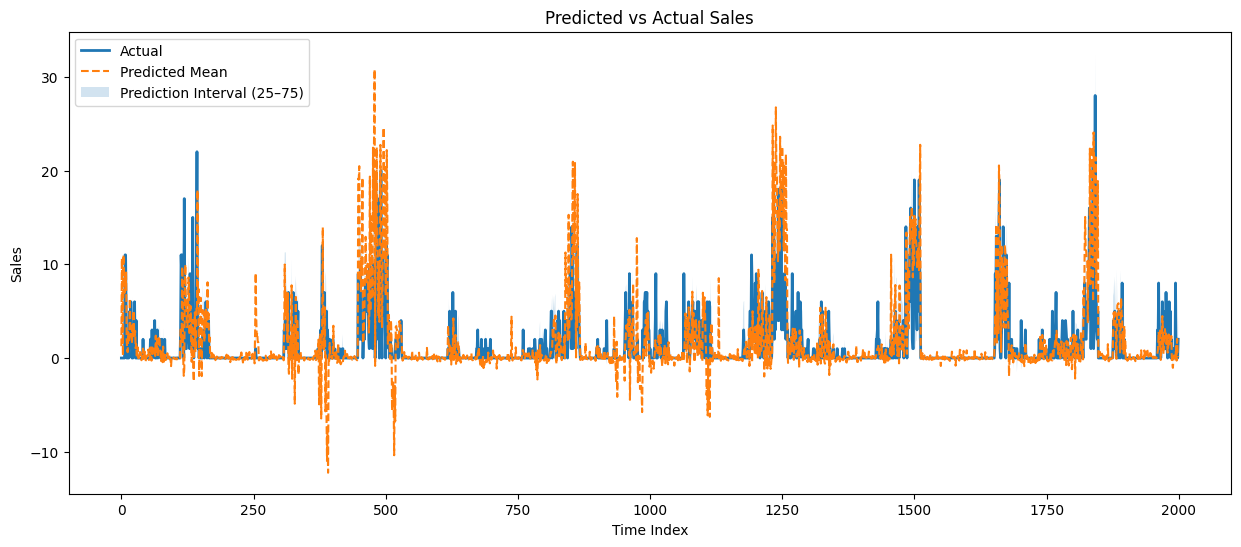

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# plot first 2000 rows across all items and days
# 2000/727 = 71 items
# plottig roughly 71 items and their days mixed together
n = 2000

y_plot = y_valid[:n]
mean_plot = pred_mean[:n]
low_plot = pred_25[:n]
high_plot = pred_75[:n]

plt.figure(figsize=(15,6))

# actual
plt.plot(y_plot, label="Actual", linewidth=2)

# predicted mean
plt.plot(mean_plot, label="Predicted Mean", linestyle="--")

# interval
plt.fill_between(
    np.arange(n),
    low_plot,
    high_plot,
    alpha=0.2,
    label="Prediction Interval (25–75)"
)

plt.legend()
plt.title("Predicted vs Actual Sales")
plt.xlabel("Time Index")
plt.ylabel("Sales")
plt.show()